<a href="https://colab.research.google.com/github/souhaylelhammadi/Introduction-l-informatique-quantique/blob/main/Informatique_Quantique_TP2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

▶ Le premier qubit subit une porte de Hadamard, puis agit
comme contrôle pour un CNOT avec le deuxième qubit.

▶ Le deuxième qubit subit une porte Hadamard après le premier
CNOT et agit ensuite comme contrôle pour un CNOT avec le
troisième qubit.

▶ Le troisième qubit subit une porte de Hadamard initiale et est
affecté par un CNOT contrôlé par le deuxième qubit.

▶ Les trois qubits sont finalement mesurés.

In [5]:

pip install cirq

In [7]:
import cirq
simulator = cirq.Simulator ()
# Creation de trois qubits
qubit_0 = cirq.NamedQubit ("q0")
qubit_1 = cirq.NamedQubit ("q1")
qubit_2 = cirq.NamedQubit ("q2")
# Construction du circuit
circuit = cirq.Circuit ()
circuit.append ( cirq.H( qubit_0 ))
circuit.append ( cirq.CNOT( qubit_0 , qubit_1 ))
circuit.append ( cirq.H ( qubit_1 ))
circuit.append ( cirq.CNOT ( qubit_1 , qubit_2 ))
circuit.append ( cirq.H ( qubit_2 ))
circuit.append ( cirq.measure ( qubit_0 , key ="m0"))
circuit.append ( cirq.measure ( qubit_1 , key ="m1"))
circuit.append ( cirq.measure ( qubit_2 , key ="m2"))


 Probabilites des etats 000  001  010  etc. : {'010 ': 0.126, '000 ': 0.129, '110 ': 0.121, '011 ': 0.127, '100 ': 0.127, '101 ': 0.12, '111 ': 0.12, '001 ': 0.13}


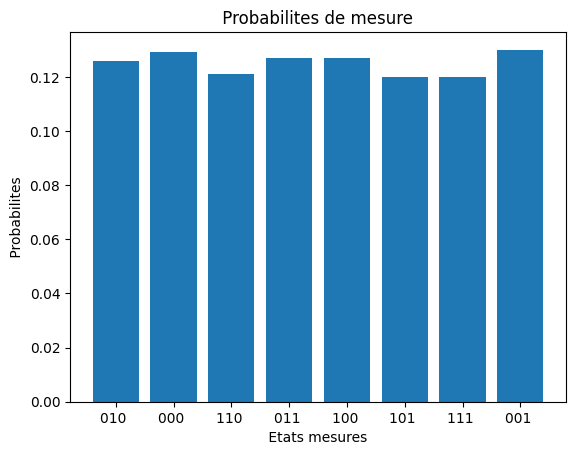

In [12]:
import matplotlib.pyplot as plt
# Simulation du circuit
repetitions = 1000
result = simulator . run ( circuit ,repetitions = repetitions )

# Comptage des resultats
histogram = result . multi_measurement_histogram( keys =["m0", "m1", "m2"])

counts = { f"{k [0]}{ k [1]}{ k [2]} ": v / repetitions
for k , v in histogram . items ()}

print (" Probabilites des etats 000 " , "001 " , "010 " , "etc. :", counts )
# Diagramme en barres
labels , values = zip (* counts . items ())
plt.bar ( labels , values )
plt . xlabel (" Etats mesures ")
plt . ylabel (" Probabilites ")
plt . title (" Probabilites de mesure ")
plt . show ()

# Moments illustrés dans un circuit

▶ Chaque ligne représente un qubit, et chaque rectangle bleu
correspond à une opération.

▶ Les Moments regroupent les opérations pouvant être

effectuées en parallèle :

▶ Moment 1 : Premières opérations sur certains qubits.

▶ Moment 2 : Opérations dépendantes des résultats du Moment
précédent.

# Implementation du circuit avec Moments

In [13]:
# Creation du circuit avec 6 qubits
mycircuit = cirq . Circuit ()
myqubits = cirq . LineQubit . range (6)
# Reinitialiser tous les qubits
reset_all_qubits = cirq . Moment ([ cirq . reset ( qubit )
for qubit in myqubits ])

mycircuit . append ( reset_all_qubits )
# Configurer le qubit de detection
setup_detect_qubit = cirq . X ( myqubits [ -1])
mycircuit . append ( setup_detect_qubit )
# Appliquer les portes de Hadamard
H_gates = cirq . Moment ( cirq . H . on_each ( myqubits ))
mycircuit . append ( H_gates )

# Appliquer les portes CNOT
mycircuit . append ([
cirq . CNOT ( myqubits [0] , myqubits [5]) ,
cirq . CNOT ( myqubits [1] , myqubits [5]) ,
cirq . CNOT ( myqubits [4] , myqubits [5]) ,
])
# Reappliquer les portes de Hadamard
mycircuit . append ( H_gates )
# Afficher le circuit
print ( mycircuit )

0: ───R───────H───@───────────H───
                  │
1: ───R───────H───┼───@───────H───
                  │   │
2: ───R───────H───┼───┼───────H───
                  │   │
3: ───R───────H───┼───┼───────H───
                  │   │
4: ───R───────H───┼───┼───@───H───
                  │   │   │
5: ───R───X───H───X───X───X───H───


# Résultats
Le circuit est structuré en Moments, où chaque groupe d’opérations
compatibles est exécuté simultanément. Les Moments incluent la
réinitialisation des qubits, la préparation du qubit 5 avec une porte
X, les superpositions créées par les portes H, et les interactions via
les CNOT.

Cette organisation optimise le parallélisme et garantit
une exécution ordonnée tout en simplifiant la lecture du circuit.

# Implementation du circuit sans Moments

In [15]:
# Creation du circuit
mycircuit = cirq . Circuit ()
myqubits = cirq . LineQubit . range (6)
# Reinitialiser les qubits sans utiliser Moment
for qubit in myqubits :
  mycircuit . append ( cirq . reset ( qubit ))
  # Configurer le qubit de detection
  mycircuit . append ( cirq . X ( myqubits [ -1]))
  # Appliquer les portes de Hadamard
for qubit in myqubits :
  mycircuit . append ( cirq . H ( qubit ))

# Appliquer les portes CNOT individuellement
mycircuit . append ( cirq . CNOT ( myqubits [0] , myqubits [5]))
mycircuit . append ( cirq . CNOT ( myqubits [1] , myqubits [5]))
mycircuit . append ( cirq . CNOT ( myqubits [4] , myqubits [5]))
# Reappliquer les portes de Hadamard individuellement
for qubit in myqubits :
  mycircuit . append ( cirq . H ( qubit ))
# Afficher le circuit
print ( mycircuit )

0: ───R───H───────────────────────────@───H───────────
                                      │
1: ───R───H───────────────────────────┼───@───H───────
                                      │   │
2: ───R───H───H───────────────────────┼───┼───────────
                                      │   │
3: ───R───H───H───────────────────────┼───┼───────────
                                      │   │
4: ───R───H───────────────────────────┼───┼───@───H───
                                      │   │   │
5: ───X───X───X───X───X───R───X───H───X───X───X───H───


# Résultats sans Moments
Sans l’utilisation de Moments, les opérations sont appliquées
individuellement et séquentiellement. Cela rend le circuit plus
verbeux et complique le parallélisme.

# Exercice

In [16]:


# simulateur
sim = cirq.Simulator()

# qubits
q = cirq.LineQubit.range(6)

circuit = cirq.Circuit()


# Moment 1 : reset
circuit.append(cirq.Moment(cirq.reset(x) for x in q))

# Moment 2 : initialisation
# q4 = |1>, q5 = X
circuit.append(cirq.Moment([
    cirq.X(q[4]),
    cirq.X(q[5])
]))

# Moment 3 : H parallèle
circuit.append(cirq.Moment(cirq.H.on_each(*q)))

# CNOT (séquentiel même cible)
circuit.append(cirq.CNOT(q[0], q[5]))
circuit.append(cirq.CNOT(q[1], q[5]))
circuit.append(cirq.CNOT(q[2], q[5]))
circuit.append(cirq.CNOT(q[3], q[5]))

# Moment : Z/X
circuit.append(cirq.Moment([
    cirq.Z(q[1]),
    cirq.X(q[2]),
    cirq.Z(q[4])
]))

# Moment : H final
circuit.append(cirq.Moment(cirq.H.on_each(*q)))

# Mesure
circuit.append(cirq.measure(*q, key="m"))

print(circuit)





0: ───R───────H───@───────────────────H───M('m')───
                  │                       │
1: ───R───────H───┼───@───────────Z───H───M────────
                  │   │                   │
2: ───R───────H───┼───┼───@───────X───H───M────────
                  │   │   │               │
3: ───R───────H───┼───┼───┼───@───────H───M────────
                  │   │   │   │           │
4: ───R───X───H───┼───┼───┼───┼───Z───H───M────────
                  │   │   │   │           │
5: ───R───X───H───X───X───X───X───────H───M────────



Probabilités :
{'101101': 1.0}


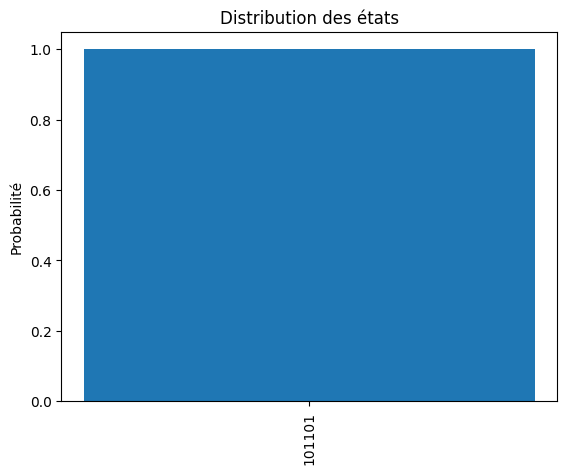

In [19]:
# Simulation
result = sim.run(circuit, repetitions=1000)

hist = result.histogram(key="m")
probs = {format(k, "06b"): v/1000 for k, v in hist.items()}

print("\nProbabilités :")
print(probs)

plt.bar(probs.keys(), probs.values())
plt.xticks(rotation=90)
plt.ylabel("Probabilité")
plt.title("Distribution des états")
plt.show()